In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
train = pd.read_csv("deliveries_train.csv")
test = pd.read_csv("deliveries_test.csv")

In [3]:
train.shape

(8000, 13)

In [4]:
train.head()

,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes
0,700001,2025-03-01 10:00:00,10,pizza,12.9,suburbs_north,2.2,2,19.24,scooter,50.0,cloudy,29
1,700003,2025-03-01 11:06:00,5,mexican,12.4,uptown,5.3,1,8.36,bike,1255.0,clear,36
2,700004,2025-03-01 11:15:00,59,pizza,11.7,suburbs_south,2.6,3,27.38,scooter,276.0,clear,31
3,700005,2025-03-01 11:28:00,51,indian,17.0,downtown,3.3,1,8.00,bike,664.0,cloudy,34
4,700006,2025-03-01 11:40:00,104,thai,11.5,suburbs_south,11.6,2,18.96,car,38.0,rain,54


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     8000 non-null   int64  
 1   order_placed_at              8000 non-null   object 
 2   restaurant_id                8000 non-null   int64  
 3   cuisine                      8000 non-null   object 
 4   restaurant_avg_prep_minutes  8000 non-null   float64
 5   city_zone                    8000 non-null   object 
 6   distance_km                  8000 non-null   float64
 7   items_count                  8000 non-null   int64  
 8   order_subtotal               8000 non-null   float64
 9   courier_vehicle              8000 non-null   object 
 10  courier_trips_completed      7671 non-null   float64
 11  weather                      7772 non-null   object 
 12  delivery_minutes             8000 non-null   int64  
dtypes: float64(4), int

In [6]:
train.describe()

,order_id,restaurant_id,restaurant_avg_prep_minutes,distance_km,items_count,order_subtotal,courier_trips_completed,delivery_minutes
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,7671.000000,8000.000000
mean,704989.228375,81.143375,13.843662,3.581812,2.79650,32.235950,355.163734,32.048750
std,2894.680014,46.528641,4.062165,2.330241,1.65482,20.951454,910.360810,11.144972
min,700001.000000,1.000000,5.000000,0.600000,1.00000,8.000000,1.000000,8.000000
25%,702482.750000,41.000000,11.500000,2.000000,2.00000,15.770000,62.000000,25.000000
50%,704969.500000,81.000000,13.400000,2.900000,2.00000,27.390000,147.000000,31.000000
75%,707519.250000,122.000000,16.800000,4.400000,4.00000,42.575000,355.000000,37.000000
max,710000.000000,160.000000,22.300000,13.300000,8.00000,127.640000,45151.000000,139.000000


In [7]:
#The target is delivery minutes

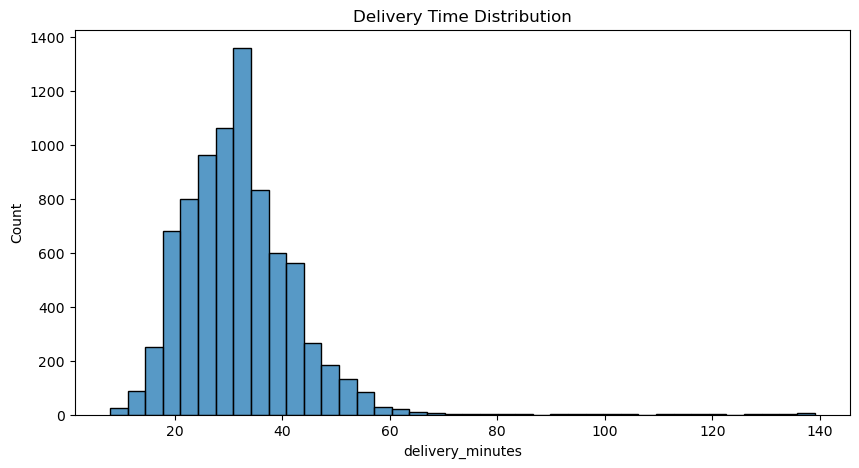

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(train["delivery_minutes"], bins=40)
plt.title("Delivery Time Distribution")
plt.show()

In [9]:
# Target Variable Analysis

# Delivery time has a roughly bell shaped distribution centered around 32 minutes. 
# The distribution is slightly right skewed, indicating a small number of unusually long deliveries. 
# Most orders are delivered within 20 to 45 minutes.

In [10]:
train["delivery_minutes"].describe()

count    8000.000000
mean       32.048750
std        11.144972
min         8.000000
25%        25.000000
50%        31.000000
75%        37.000000
max       139.000000
Name: delivery_minutes, dtype: float64

In [11]:
train.sort_values("delivery_minutes",ascending=False).head(20)

,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes
4107,705101,2025-06-02 20:39:00,7,thai,17.1,midtown,3.7,1,8.00,car,216.0,clear,139
5677,707105,2025-07-10 12:24:00,121,indian,13.9,suburbs_north,3.5,4,50.78,car,207.0,cloudy,137
1934,702403,2025-04-13 12:48:00,132,mexican,13.3,downtown,2.6,1,11.68,scooter,283.0,heavy_rain,137
6391,708002,2025-07-26 18:24:00,15,indian,18.1,midtown,2.3,8,108.89,scooter,472.0,cloudy,136
4904,706112,2025-06-21 13:12:00,27,thai,16.7,downtown,0.9,8,81.60,scooter,87.0,clear,136
5416,706774,2025-07-03 21:50:00,46,indian,19.4,downtown,1.2,3,26.86,car,29.0,rain,135
976,701213,2025-03-22 20:19:00,78,mexican,9.1,downtown,2.3,2,26.18,bike,10.0,rain,135
2637,703263,2025-04-29 17:31:00,133,chinese,15.9,suburbs_north,5.4,2,24.70,car,7.0,clear,133
1238,701541,2025-03-29 12:01:00,137,thai,13.3,suburbs_north,8.3,2,15.95,car,50.0,clear,131
5042,706292,2025-06-24 19:13:00,142,indian,20.4,midtown,3.5,3,33.05,scooter,1501.0,clear,131


In [12]:
train.isnull().sum().sort_values(ascending=False)

courier_trips_completed        329
weather                        228
order_id                         0
order_placed_at                  0
restaurant_id                    0
cuisine                          0
restaurant_avg_prep_minutes      0
city_zone                        0
distance_km                      0
items_count                      0
order_subtotal                   0
courier_vehicle                  0
delivery_minutes                 0
dtype: int64

In [13]:
# courier_trips_completed 329 , weather 228

In [14]:
missing_pct = train.isnull().mean() * 100
missing_pct.sort_values(ascending=False)

courier_trips_completed        4.1125
weather                        2.8500
order_id                       0.0000
order_placed_at                0.0000
restaurant_id                  0.0000
cuisine                        0.0000
restaurant_avg_prep_minutes    0.0000
city_zone                      0.0000
distance_km                    0.0000
items_count                    0.0000
order_subtotal                 0.0000
courier_vehicle                0.0000
delivery_minutes               0.0000
dtype: float64

In [15]:
# Missing Value Analysis 
# Only two features contain missing values: courier_trips_completed: 329 missing values (4.11%)
# weather: 228 missing values (2.85%)
# Because the missing percentages are small, missing values will be imputed during preprocessing rather than removing records

In [16]:
# Investigating the target outliers properly

In [17]:
train["delivery_minutes"].quantile([0.01, 0.05, 0.95, 0.99])

0.01    14.0
0.05    18.0
0.95    49.0
0.99    62.0
Name: delivery_minutes, dtype: float64

In [18]:
# Almost all deliveries are between 14 and 62 minutes

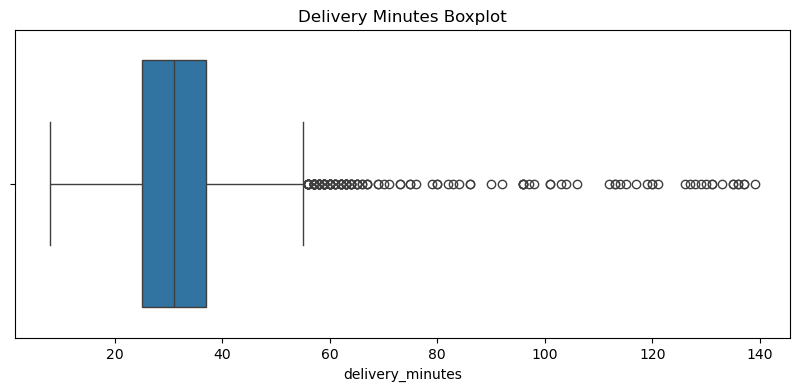

In [19]:
plt.figure(figsize=(10,4))
sns.boxplot(x=train["delivery_minutes"])
plt.title("Delivery Minutes Boxplot")
plt.show()

In [20]:
# Q1 = 25 mins, Median = 31 mins,Q3 = 37 mins
# 60 70 80 90 100 120 139 are outliers, deliveries that took unusually long compared to most orders

# Most deliveries = 20 to 45 mins, But some deliveries took: 80,100,120,139
# These extreme cases can pull the model in the wrong direction, The model may learn patterns from those that don't represent normal operations.
# Before removing anything, checking what causes those extreme deliveries

In [21]:
train.sort_values("delivery_minutes", ascending=False).head(20)

,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes
4107,705101,2025-06-02 20:39:00,7,thai,17.1,midtown,3.7,1,8.00,car,216.0,clear,139
5677,707105,2025-07-10 12:24:00,121,indian,13.9,suburbs_north,3.5,4,50.78,car,207.0,cloudy,137
1934,702403,2025-04-13 12:48:00,132,mexican,13.3,downtown,2.6,1,11.68,scooter,283.0,heavy_rain,137
6391,708002,2025-07-26 18:24:00,15,indian,18.1,midtown,2.3,8,108.89,scooter,472.0,cloudy,136
4904,706112,2025-06-21 13:12:00,27,thai,16.7,downtown,0.9,8,81.60,scooter,87.0,clear,136
5416,706774,2025-07-03 21:50:00,46,indian,19.4,downtown,1.2,3,26.86,car,29.0,rain,135
976,701213,2025-03-22 20:19:00,78,mexican,9.1,downtown,2.3,2,26.18,bike,10.0,rain,135
2637,703263,2025-04-29 17:31:00,133,chinese,15.9,suburbs_north,5.4,2,24.70,car,7.0,clear,133
1238,701541,2025-03-29 12:01:00,137,thai,13.3,suburbs_north,8.3,2,15.95,car,50.0,clear,131
5042,706292,2025-06-24 19:13:00,142,indian,20.4,midtown,3.5,3,33.05,scooter,1501.0,clear,131


In [22]:
# Some of the slowest deliveries have
# Long distances (8.3 km, 10.6 km)
# Large orders (8 items)
# Higher prep times (17 to 20 min)
# Car deliveries in suburban zones
# All of these are plausible reasons for delays.

In [23]:
# The target variable contains a small number of extreme delivery times above the 99th percentile which is 62 minutes
# Manual inspection showed these observations correspond to realistic business scenarios such as longer distances, larger orders 
# and higher restaurant preparation times. Therefore, they're retained for modeling.

In [24]:
# Checking if distance is really driving delivery time

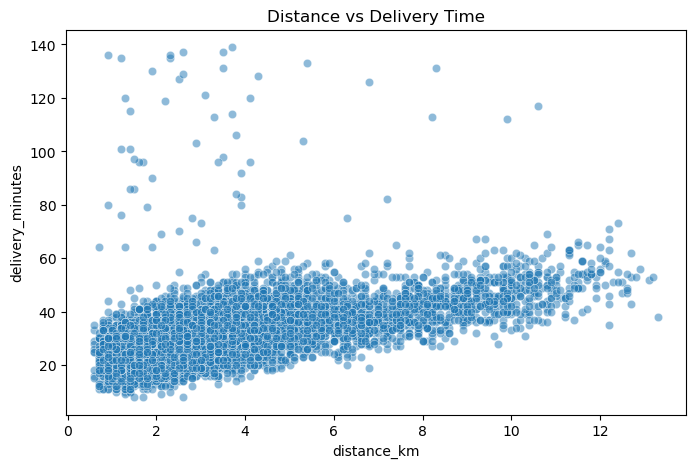

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=train,x="distance_km",y="delivery_minutes",alpha=0.5)
plt.title("Distance vs Delivery Time")

plt.show()

In [26]:
train[["distance_km","delivery_minutes"]].corr()

,distance_km,delivery_minutes
distance_km,1.000000,0.530952
delivery_minutes,0.530952,1.000000


In [27]:
train["weather"].value_counts(dropna=False)

weather
clear         4522
cloudy        1828
rain          1011
heavy_rain     411
NaN            228
Name: count, dtype: int64

In [28]:
train["courier_vehicle"].value_counts()

courier_vehicle
scooter    3149
bike       2567
car        2284
Name: count, dtype: int64

In [29]:
train["cuisine"].value_counts()

cuisine
thai       1500
pizza      1330
indian     1209
mexican     951
salads      946
chinese     801
sushi       775
burgers     488
Name: count, dtype: int64

In [30]:
# There is a moderate to strong positive relationship between delivery distance and delivery time 
# Meaning to say Longer trips generally take longer. The upward trend in the scatter plot confirms this

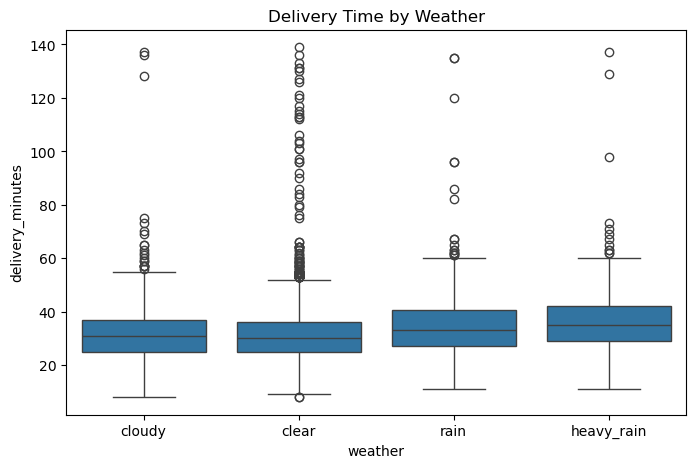

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train, x="weather", y="delivery_minutes")
plt.title("Delivery Time by Weather")

plt.show()

In [32]:
# Weather Impact
# Weather shows a clear relationship with delivery times. Orders placed during rain and heavy rain
# it generally take longer than orders placed during clear or cloudy conditions. 
# Heavy rain has the highest median delivery time and greater variability, indicating both slower and less predictable deliveries.

In [33]:
# Courier Vehicle Distribution

In [34]:
train["courier_vehicle"].value_counts()

courier_vehicle
scooter    3149
bike       2567
car        2284
Name: count, dtype: int64

In [35]:
# Courier Vehicle Distribution
# Bikes are the most frequently used delivery vehicle.
# Scooters and cars are also well represented in the dataset.
# The vehicle categories are fairly balanced, reducing the risk of model bias.

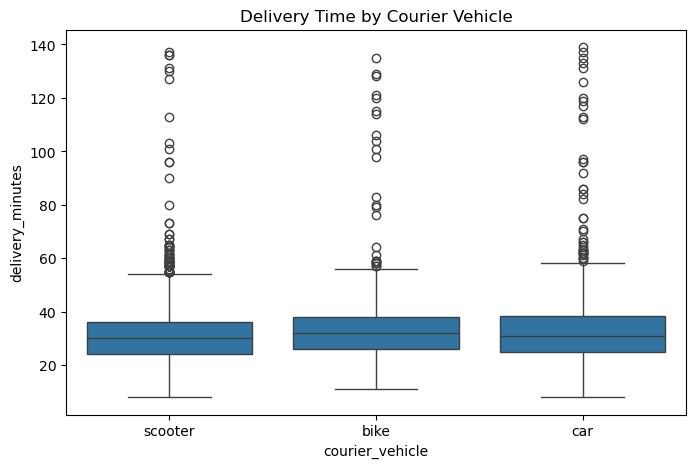

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train, x="courier_vehicle", y="delivery_minutes")
plt.title("Delivery Time by Courier Vehicle")

plt.show()

In [37]:
# Courier Vehicle Impact
# Delivery times are broadly similar across scooters, bikes, and cars.
# Bikes and cars show slightly higher median delivery times than scooters.
# All vehicle types exhibit a wide range of delivery durations and several extreme outliers.
# Vehicle type appears to influence delivery time, but the effect is likely weaker than factors such as distance or restaurant preparation time.

In [38]:
# Restaurent Average Preparation Minutes

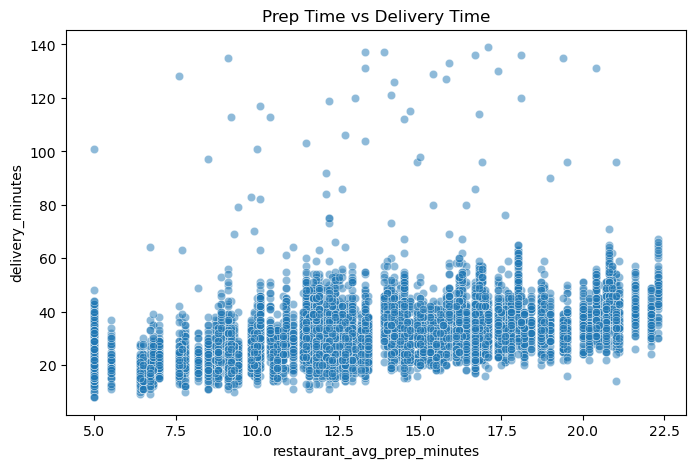

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot( data=train,
x="restaurant_avg_prep_minutes", y="delivery_minutes", alpha=0.5)
plt.title("Prep Time vs Delivery Time")

plt.show()

In [40]:
train[[ "restaurant_avg_prep_minutes", "delivery_minutes"]].corr()

,restaurant_avg_prep_minutes,delivery_minutes
restaurant_avg_prep_minutes,1.000000,0.405956
delivery_minutes,0.405956,1.000000


In [41]:
# The correlation between restaurant average prep time and delivery time is approximately 0.41.
# 0.41 indicates a moderate positive relationship (-1 Perfect negative relationship , 0 No relationship ,+1 Perfect positive relationship)
# Restaurants that typically take longer to prepare food tend to have longer overall delivery times

In [42]:
# Comparison

# Feature                      =  # Correlation with Delivery Time
# distance_km                  =   0.531
# restaurant_avg_prep_minutes  =    0.406

# Distance appears to be a stronger predictor of delivery time than restaurant preparation time, although 
# both show meaningful positive relationships.

In [43]:
# Restaurant Preparation Time Analysis

# The correlation between restaurant_avg_prep_minutes and delivery_minutes is 0.406,
# indicating a moderate positive relationship.
# Orders from restaurants with longer average preparation times generally
# experience longer total delivery durations.
# Although preparation time is an important predictor, distance_km shows an even
# stronger correlation with delivery time (0.531).

In [44]:
# Feature Engineering

In [45]:
train["order_placed_at"] = pd.to_datetime(train["order_placed_at"])
test["order_placed_at"] = pd.to_datetime(test["order_placed_at"])

In [46]:
train["hour"] = train["order_placed_at"].dt.hour
train["day_of_week"] = train["order_placed_at"].dt.dayofweek
train["month"] = train["order_placed_at"].dt.month
train["is_weekend"] = (train["day_of_week"] >= 5).astype(int)
train["subtotal_per_item"] = (train["order_subtotal"] / train["items_count"])
train["distance_x_prep"] = (train["distance_km"] *train["restaurant_avg_prep_minutes"])

In [47]:
test["hour"] = test["order_placed_at"].dt.hour
test["day_of_week"] = test["order_placed_at"].dt.dayofweek
test["month"] = test["order_placed_at"].dt.month
test["is_weekend"] = (test["day_of_week"] >= 5).astype(int)
test["subtotal_per_item"] = (test["order_subtotal"] / test["items_count"])
test["distance_x_prep"] = (test["distance_km"] *test["restaurant_avg_prep_minutes"])

In [48]:
train.head()

,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes,hour,day_of_week,month,is_weekend,subtotal_per_item,distance_x_prep
0,700001,2025-03-01 10:00:00,10,pizza,12.9,suburbs_north,2.2,2,19.24,scooter,50.0,cloudy,29,10,5,3,1,9.620000,28.38
1,700003,2025-03-01 11:06:00,5,mexican,12.4,uptown,5.3,1,8.36,bike,1255.0,clear,36,11,5,3,1,8.360000,65.72
2,700004,2025-03-01 11:15:00,59,pizza,11.7,suburbs_south,2.6,3,27.38,scooter,276.0,clear,31,11,5,3,1,9.126667,30.42
3,700005,2025-03-01 11:28:00,51,indian,17.0,downtown,3.3,1,8.00,bike,664.0,cloudy,34,11,5,3,1,8.000000,56.10
4,700006,2025-03-01 11:40:00,104,thai,11.5,suburbs_south,11.6,2,18.96,car,38.0,rain,54,11,5,3,1,9.480000,133.40


In [49]:
train.columns

Index(['order_id', 'order_placed_at', 'restaurant_id', 'cuisine',
       'restaurant_avg_prep_minutes', 'city_zone', 'distance_km',
       'items_count', 'order_subtotal', 'courier_vehicle',
       'courier_trips_completed', 'weather', 'delivery_minutes', 'hour',
       'day_of_week', 'month', 'is_weekend', 'subtotal_per_item',
       'distance_x_prep'],
      dtype='object')

In [50]:
y = train["delivery_minutes"]
X = train.drop(columns=["delivery_minutes","order_id","order_placed_at"])
X_test = test.drop(columns=["order_id","order_placed_at"])

In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (8000, 16)
y shape: (8000,)
X_test shape: (2000, 16)


In [52]:
# For a valid approach
# Creating Train / Validation Split

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.20,random_state=42)

In [54]:
print(X_train.shape)
print(X_valid.shape)

(6400, 16)
(1600, 16)


In [55]:
# Creating a Preprocessing Pipeline

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [57]:
# Categorical Features

In [58]:
categorical_features = ["cuisine","city_zone","courier_vehicle","weather"]

In [59]:
# Numerical Features

In [60]:
numeric_features = ["restaurant_id","restaurant_avg_prep_minutes","distance_km","items_count","order_subtotal","courier_trips_completed","hour","day_of_week","month","is_weekend","subtotal_per_item","distance_x_prep"]

In [61]:
# Transformers

In [62]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [63]:
# Preprocessor

In [64]:
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])

In [65]:
# Baseline Model

In [66]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

In [67]:
baseline_model = Pipeline([("preprocessor", preprocessor),("model", DummyRegressor(strategy="mean"))])

In [68]:
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_valid)
baseline_mae = mean_absolute_error(y_valid,baseline_preds)
print("Baseline MAE:", baseline_mae)

Baseline MAE: 7.630796875000001


In [69]:
# On average, the prediction is off by about 7.6 minutes
# A score that every real model must beat.

In [70]:
#

In [71]:
# Linear Regression

In [72]:
from sklearn.linear_model import LinearRegression
lr_model = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())])
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_valid)
lr_mae = mean_absolute_error(y_valid,lr_preds)
print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 3.6432457919084875


In [73]:
# Baseline MAE = 7.63 , Linear Regression MAE = 3.64
# Linear Regression model reduced prediction error
# improvement = ((7.63 - 3.64) / 7.63) * 100
# 52.2% improvement over baseline
# Requirement satisfied.

In [74]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = Pipeline([("preprocessor", preprocessor),("model", GradientBoostingRegressor(random_state=42))])
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_valid)
gb_mae = mean_absolute_error(y_valid, gb_preds)
print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting MAE: 3.3638869471698754


In [75]:
# For Gradient Boosting (7.63 - 3.36) / 7.63 × 100 = 55.9% improvement

In [76]:
# Model Comparison and Selection

# Baseline Model -
# The baseline model used a DummyRegressor that predicts the average delivery time for every order.
# MAE: 7.63 minutes
# This serves as a benchmark to evaluate whether more sophisticated models provide meaningful improvements.

# Linear Regression - 
# A Linear Regression model was trained using all engineered and preprocessed features.
# MAE: 3.64 minutes
# The model significantly outperformed the baseline, reducing prediction error by approximately 52%. 
# This indicates that delivery time is strongly influenced by the available order, restaurant, courier, and weather information.

# Gradient Boosting Regressor - 
# A Gradient Boosting Regressor was trained using the same preprocessing pipeline.
# MAE: 3.36 minutes
# This model achieved the lowest prediction error among the evaluated approaches and improved performance by approximately 56% 
# compared to the baseline model.

# Final Model Selection
# The Gradient Boosting Regressor was selected as the final model because it achieved the best validation performance with an MAE of 3.36 minutes.
# Tree based ensemble models can capture nonlinear relationships and interactions between variables that linear models may miss. 
# For example, the combined effect of long delivery distances, poor weather conditions, and high restaurant preparation 
# times can be modeled more effectively by Gradient Boosting.
# Therefore, the Gradient Boosting Regressor was chosen to generate predictions for the held-out test dataset.

results = pd.DataFrame({"Model": ["Baseline", "Linear Regression", "Gradient Boosting"],"MAE": [baseline_mae, lr_mae, gb_mae]})
results.sort_values("MAE")

,Model,MAE
2,Gradient Boosting,3.363887
1,Linear Regression,3.643246
0,Baseline,7.630797


In [77]:
# Business Takeaway

# The final model reduces average prediction error from 7.63 minutes to 3.36 minutes, improving ETA accuracy by nearly 56%.
# More accurate delivery estimates can improve customer satisfaction, reduce refund requests, and provide a better delivery experience.

In [78]:
feature_names = gb_model.named_steps["preprocessor"].get_feature_names_out()
importance = gb_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"feature": feature_names,"importance": importance})
importance_df = importance_df.sort_values(by="importance",ascending=False)
importance_df.head(15)

,feature,importance
11,num__distance_x_prep,0.688725
1,num__restaurant_avg_prep_minutes,0.070376
25,cat__courier_vehicle_bike,0.045849
6,num__hour,0.033844
2,num__distance_km,0.027976
4,num__order_subtotal,0.025996
3,num__items_count,0.021431
5,num__courier_trips_completed,0.020261
30,cat__weather_heavy_rain,0.016472
31,cat__weather_rain,0.008415


In [79]:
# Feature Importance Analysis

# The most important feature is distance_x_prep, indicating that the combination of
# delivery distance and restaurant preparation time is a strong driver of delivery duration.

# Restaurant_avg_prep_minutes is also highly important, confirming that longer food
# preparation times are associated with longer delivery times.

# Hour of day is another important predictor, suggesting that demand patterns and
# peak periods can influence delivery performance.

# Distance_km remains a strong predictor even after creating the interaction feature,
# highlighting the impact of travel distance on delivery duration.

# Order size variables such as order_subtotal and items_count also contribute to the model,
# indicating that larger orders may require additional preparation and handling time.

# Courier experience and weather conditions, especially heavy rain, also affect delivery times,
# although their influence is smaller than distance and preparation-related features.

# Overall, the model suggests that delivery delays are primarily influenced by a combination
# of travel distance, restaurant preparation time, order size, time of day, courier experience,
# and weather conditions.